In [1]:
## 2026.08.20 CODEX GIST counterpart of CODEX_hcc/HCC_histology_derived_niche_index.ipynb
##            TLS / SRI / TNI from StarDist Level-2 softmax on s1167 matched nuclei
## 2026.08.27 Shared engine: code/Hist2Pheno_pkg/histology_niche_index.py
##            GIST paths/clinical: code/CODEX_gist/gist_histology_derived_niche_index.py
## 2026.09.01 use the trained model on 2026-08-28 20:43:53 result_all_spatial_gist

## 1. Load predicted cell-type probabilities (soft abundance)

This notebook is the **CODEX GIST (s1167)** analog of `CODEX_hcc/HCC_histology_derived_niche_index.ipynb`.

It uses pooled StarDist matched-AUROC predictions under `s1167/result_all_spatial_gist/stardist/{ACQUISITION_ID}/`.

| Source | Predictions | Coordinates |
|--------|-------------|-------------|
| **Matched AUROC** | `stardist/{acq}/validation_external_stardist_matched_AUROC.csv` | `s1167/{acq}/{acq}_matched_features_stardist.h5ad` (`obsm['spatial_HE']`) |

**Demo core:** `Charvill-94_c013_v001_r001_reg002`. Cohort = annotated GIST cores (550).

There is **no Response** field. Clinical grouping in §6 follows the Pred notebook: **coverslip** (c009 / c011 / c013) plus recoded GIST TMA fields (`site`, `size`, `mitotic_rate`, `mutation_status`, `risk`, `primary`, `tma_position`). **SAMPLE_LABEL** is not used as a scatter legend.

GIST Level-2 adds Endothelial cells, Stromal cells, T cells, Monocytes, DCs on top of the PDAC set.

Shared TLS / SRI / TNI math: `Hist2Pheno_pkg/histology_niche_index.py` (`OrganNicheConfig` for `codex_gist`).  
This notebook keeps GIST paths and clinical loaders in `gist_histology_derived_niche_index.py`. Spatial maps still reuse Xenium `plot_ari_fri_*` helpers with SRI/TNI column names. Do not import PDAC and GIST niche wrappers in the same kernel (`configure()` is global).


In [2]:
import sys
import importlib
from pathlib import Path

import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "/home/lingyu/ssd2/Python/"
_repo = Path(f"{path}Hist2Pheno/code")
for _p in (_repo / "Hist2Pheno_pkg", _repo / "Xenium_lung", _repo / "CODEX_pdac", _repo / "CODEX_gist"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import histology_niche_index as hni
importlib.reload(hni)
import s1167_histology_derived_niche_index as s1167_ni
importlib.reload(s1167_ni)
import gist_histology_derived_niche_index as gist_ni
importlib.reload(gist_ni)

DATA_ROOT = gist_ni.DEFAULT_DATA_ROOT
CASES_ROOT = gist_ni.DEFAULT_CASES_ROOT
STARDIST_ROOT = gist_ni.DEFAULT_STARDIST_ROOT
OUT_DIR = DATA_ROOT / "result_all_spatial_gist" / "niche_index_gist"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("STARDIST :", STARDIST_ROOT)
print("OUT_DIR  :", OUT_DIR)
print("shared   :", hni.__file__)
print("organ    :", gist_ni.cfg().pan_organ, gist_ni.cfg().tls_t)


DATA_ROOT: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167
STARDIST : /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_gist/stardist
OUT_DIR  : /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_gist/niche_index_gist
shared   : /home/lingyu/ssd2/Python/Hist2Pheno/code/Hist2Pheno_pkg/histology_niche_index.py
organ    : codex_gist ('T cells', 'Cytotoxic T cells', 'Helper T cells', 'Tregs')


In [3]:
SAMPLE = gist_ni.DEFAULT_DEMO_SAMPLE
RADIUS_UM = gist_ni.DEFAULT_SPATIAL_RADIUS_UM
UM_PER_PX = gist_ni.DEFAULT_UM_PER_HE_PIXEL

clinical = gist_ni.load_s1167_clinical_info()
annotation = gist_ni.load_s1167_annotation()
ALL_SAMPLES = gist_ni.discover_s1167_spatial_samples(clinical, require_h5ad=True)
paths = gist_ni.s1167_spatial_paths(SAMPLE)

print(f"Demo core: {SAMPLE}")
print(f"Annotated cores with AUROC+h5ad: {len(ALL_SAMPLES)}")
print("AUROC:", paths.auroc_csv)
print("h5ad :", paths.stardist_h5ad)
print(f"Spatial radius: {RADIUS_UM} μm | μm/px={UM_PER_PX}")
display(gist_ni.index_formula_table())
display(annotation)
display(clinical.head())


Clinical rows: 550 (cohort=GIST TMA)


,ACQUISITION_ID,coverslip,SAMPLE_LABEL,SAMPLE_ID,tissue_type
0,Charvill-94_c011_v001_r001_reg002,c011,TA-429A_2,31016.0,GIST TMA
1,Charvill-94_c011_v001_r001_reg003,c011,TA-429A_3,31017.0,GIST TMA
2,Charvill-94_c011_v001_r001_reg004,c011,TA-429A_4,31018.0,GIST TMA
3,Charvill-94_c011_v001_r001_reg007,c011,TA-429A_7,31025.0,GIST TMA
4,Charvill-94_c011_v001_r001_reg010,c011,TA-429A_10,31030.0,GIST TMA
5,Charvill-94_c011_v001_r001_reg011,c011,TA-429A_11,31031.0,GIST TMA
6,Charvill-94_c011_v001_r001_reg012,c011,TA-429A_14,31022.0,GIST TMA
7,Charvill-94_c011_v001_r001_reg014,c011,TA-429A_16,30993.0,GIST TMA
8,Charvill-94_c011_v001_r001_reg016,c011,TA-429A_18,30979.0,GIST TMA
9,Charvill-94_c011_v001_r001_reg026,c011,TA-429A_28,30957.0,GIST TMA



coverslip


coverslip
c011    197
c013    193
c009    160
Name: count, dtype: int64


SAMPLE_LABEL


SAMPLE_LABEL
TA-429B       193
TA-339_139      1
TA-339_133      1
TA-339_125      1
TA-339_28       1
             ... 
TA-339_12       1
TA-339_11       1
TA-339_9        1
TA-339_8        1
TA-339_27       1
Name: count, Length: 358, dtype: int64

Demo core: Charvill-94_c013_v001_r001_reg002
Annotated cores with AUROC+h5ad: 550
AUROC: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_gist/stardist/Charvill-94_c013_v001_r001_reg002/validation_external_stardist_matched_AUROC.csv
h5ad : /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c013_v001_r001_reg002/Charvill-94_c013_v001_r001_reg002_matched_features_stardist.h5ad
Spatial radius: 55.0 μm | μm/px=0.5


,index,hcc_analog,formula
0,TLS,TLS,sum(B cells+ T cells+ Cytotoxic T cells+ Helpe...
1,TLS_spatial,TLS_spatial,(B_local × T_local × DC_local)^(1/3) within ra...
2,SRI_ratio,SRI_ratio,Fibroblasts+Stromal cells / Epithelial cells
3,SRI_spatial,SRI_spatial,Fib_local / Epi_local within radius R μm
4,TNI_ratio,TNI_ratio,(Fibroblasts+Stromal cells + Macrophages+Monoc...
5,TNI_spatial,TNI_spatial,(Fib_local × myeloid_local × Endo_local)^(1/3)...


,cohort,celltype_level2,celltype_level1,celltype_level0
0,GIST TMA,Epithelial cells,Epithelial,Epithelial
1,GIST TMA,Fibroblasts,Stromal,Stromal
2,GIST TMA,Stromal cells,Stromal,Stromal
3,GIST TMA,Helper T cells,T cells,Immune
4,GIST TMA,Tregs,T cells,Immune
5,GIST TMA,T cells,T cells,Immune
6,GIST TMA,Monocytes,Myeloid,Immune
7,GIST TMA,Neutrophils,Myeloid,Immune
8,GIST TMA,DCs,Myeloid,Immune
9,GIST TMA,B cells,B cells,Immune


,ACQUISITION_ID,SAMPLE_LABEL,SAMPLE_ID,tissue_type,tissue_subtype,diagnosis,tma_position,site,size,mitotic_rate,mutation_status,risk,primary,PATIENT_ID,species,treatment,prefix,cohort,tissue_type_filled,coverslip
0,Charvill-94_c011_v001_r001_reg002,TA-429A_2,31016.0,GIST TMA,NaN,NaN,4_8_13,liver - right lobe,NaN,NaN,KIT 11,malignant,met (primary unknown),13489.0,human,NaN,Charvill-94_c011,GIST TMA,GIST TMA,c011
1,Charvill-94_c011_v001_r001_reg003,TA-429A_3,31017.0,GIST TMA,NaN,NaN,4_8_12,liver - right lobe,NaN,NaN,KIT 11,malignant,met (primary unknown),13489.0,human,NaN,Charvill-94_c011,GIST TMA,GIST TMA,c011
2,Charvill-94_c011_v001_r001_reg004,TA-429A_4,31018.0,GIST TMA,NaN,NaN,4_8_11,Stomach,NaN,NaN,PDGFRA 18,malignant,primary,13490.0,human,NaN,Charvill-94_c011,GIST TMA,GIST TMA,c011
3,Charvill-94_c011_v001_r001_reg007,TA-429A_7,31025.0,GIST TMA,NaN,NaN,4_8_8,stomach and esophagus,NaN,NaN,Wildtype,malignant,primary,13493.0,human,NaN,Charvill-94_c011,GIST TMA,GIST TMA,c011
4,Charvill-94_c011_v001_r001_reg010,TA-429A_10,31030.0,GIST TMA,NaN,NaN,4_8_5,small intestine,NaN,NaN,KIT 11,malignant,primary,13496.0,human,NaN,Charvill-94_c011,GIST TMA,GIST TMA,c011


In [4]:
df, class_names, probs = gist_ni.load_stardist_auroc_csv(
    paths.auroc_csv, paths.class_names_csv,
)
missing = gist_ni.missing_index_cell_types(class_names)
print(f"{SAMPLE}: {len(df):,} cells, {len(class_names)} classes")
print("classes:", class_names)
if missing:
    raise KeyError(f"Missing index compartments in class_names: {missing}")
df.head(3)


Charvill-94_c013_v001_r001_reg002: 2,215 cells, 11 classes
classes: ['B cells', 'DCs', 'Endothelial cells', 'Epithelial cells', 'Fibroblasts', 'Helper T cells', 'Monocytes', 'Neutrophils', 'Stromal cells', 'T cells', 'Tregs']


,cell_id,ground_truth_final_CT,predict_stardist_final_CT,ground_truth_idx,predict_stardist_idx,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,prob_10
0,2,Tregs,Neutrophils,10,7,0.036247,0.059765,0.059860,0.045066,0.231450,0.038698,0.111105,0.249525,0.010259,0.025892,0.132134
1,4,Tregs,Tregs,10,10,0.023748,0.109919,0.026532,0.040744,0.129453,0.053374,0.063719,0.225980,0.010704,0.041104,0.274722
2,7,Tregs,Neutrophils,10,7,0.020810,0.015556,0.012044,0.003502,0.141656,0.111950,0.095150,0.315199,0.006340,0.007663,0.270131


## 2. Compute histology-derived indices (abundance)

GIST indices use **Level-2 softmax** (soft abundance per nucleus).

| Index | Formula | HCC analog |
|-------|---------|------------|
| **TLS** | B + T cells (+ Cytotoxic/Helper/Tregs if present) + DC/DCs | TLS |
| **SRI_ratio** | (Fibroblasts + Stromal cells) / Epithelial cells | SRI |
| **TNI_ratio** | (Fib/Stromal + Macrophages/Monocytes + Endothelial) / epithelium | TNI |

**Read order:** SRI → TNI → TLS. High SRI alone = epithelial mass replaced by stroma. High SRI **and** TNI = active CAF / macrophage / endothelial niche.


In [5]:
df_idx = gist_ni.add_abundance_indices(df, probs, class_names)
sample_summary = gist_ni.summarize_indices_by_sample(df_idx, SAMPLE)
display(sample_summary)
df_idx.filter(regex="^(cell_id|predict_stardist|idx_)").head()


,Sample,n_cells,idx_TLS,idx_SRI_ratio,idx_TNI_ratio
0,Charvill-94_c013_v001_r001_reg002,2215,0.52341,95.77905,195.869968


,cell_id,predict_stardist_final_CT,predict_stardist_idx,idx_TLS,idx_SRI_ratio,idx_TNI_ratio
0,2,Neutrophils,7,0.292736,5.363416,9.157057
1,4,Tregs,10,0.502867,3.439937,5.655013
2,7,Neutrophils,7,0.426109,42.265968,72.879157
3,8,Neutrophils,7,0.266540,35.285079,53.144041
4,9,Helper T cells,5,0.668827,3.244859,13.345915


## 3. Spatial TLS (B / T / DC co-localization)

**TLS_spatial** = `(B_local × T_local × DC_local)^(1/3)` within radius **R μm**.

Cyan points = `tls_candidate` (top 5% `idx_TLS_spatial` on this core).


In [6]:
df_spatial, class_names_sp, probs_sp, coords, paths_sp, um_px = gist_ni.load_sample_with_spatial_indices(
    SAMPLE, radius_um=RADIUS_UM, um_per_pixel=UM_PER_PX,
)
print(f"{SAMPLE} | μm/px={um_px:.4f} | R={RADIUS_UM} μm | n={len(df_spatial):,}")
print("TLS hotspot:", gist_ni.summarize_tls_hotspots(df_spatial))
cols = [
    "cell_id", "coord_x", "coord_y", "idx_TLS", "idx_TLS_spatial",
    "idx_SRI_spatial", "idx_TNI_spatial", "tls_candidate", "sri_candidate", "tni_candidate",
]
display(
    df_spatial.loc[df_spatial["tls_candidate"], cols]
    .sort_values("idx_TLS_spatial", ascending=False)
    .head(5)
)


Charvill-94_c013_v001_r001_reg002 | μm/px=0.5000 | R=55.0 μm | n=2,215
TLS hotspot: {'n_cells_total': 2215, 'n_candidate_cells': 111, 'fraction_candidate': 0.05011286681715576, 'max_tls_spatial': 0.14821514483281917, 'mean_tls_spatial_candidate': 0.12526938221704506, 'centroid_x': 914.4054054054054, 'centroid_y': 1198.981981981982}


,cell_id,coord_x,coord_y,idx_TLS,idx_TLS_spatial,idx_SRI_spatial,idx_TNI_spatial,tls_candidate,sri_candidate,tni_candidate
1846,2850,724.0,1283.0,0.721323,0.148215,12.581764,7.491890,True,False,False
1877,2889,650.0,1299.0,0.843321,0.147542,39.448958,21.488396,True,False,False
1872,2882,672.0,1295.0,0.799884,0.146595,19.917398,11.059716,True,False,False
1820,2810,621.0,1269.0,0.518869,0.144872,18.786254,12.801851,True,False,False
1873,2883,703.0,1295.0,0.783127,0.144729,17.324475,10.114832,True,False,False


(<Figure size 1080x300 with 4 Axes>,
 array([<Axes: title={'center': 'Charvill-94_c013_v001_r001_reg002 (CODEX GIST): Abundance TLS (idx_TLS)'}>,
        <Axes: title={'center': 'Charvill-94_c013_v001_r001_reg002 (CODEX GIST): Spatial TLS (R=55 μm)'}>],
       dtype=object))

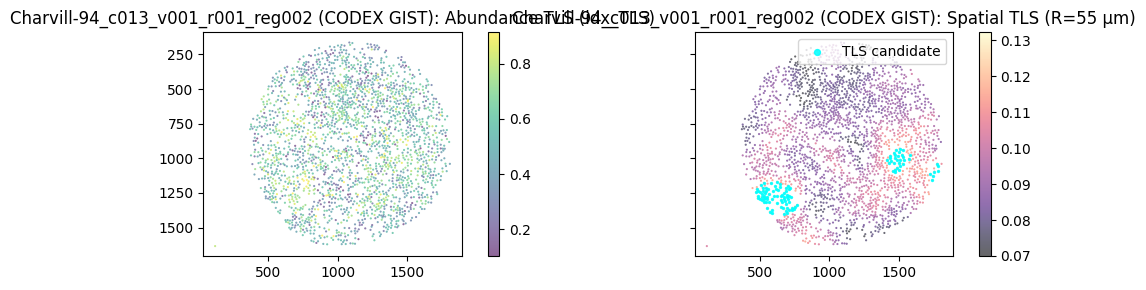

In [7]:
gist_ni.plot_tls_abundance_vs_spatial(
    df_spatial, f"{SAMPLE} (CODEX GIST)",
    radius_um=RADIUS_UM, figsize=(18.0 * 0.6, 5.0 * 0.6), dpi=150,
)


## 4. Spatial SRI / TNI (stromal remodeling → active TME niche)

1. **SRI** — local fibroblasts vs epithelium.
2. **TNI** — co-localized fibroblasts × macrophages × endothelium / epithelium.
3. **TLS** — adaptive immune aggregate.

High SRI **and** high TNI → active immunosuppressive / angiogenic microenvironment.


,cell_id,coord_x,coord_y,idx_SRI_ratio,idx_SRI_spatial,idx_TNI_ratio,idx_TNI_spatial,sri_candidate,tni_candidate
1961,3028,553.0,1358.0,129.197780,117.327452,212.384082,55.188486,True,True
1343,2071,1220.0,1002.0,523.021116,99.542712,873.333997,53.922509,True,True
1230,1909,1221.0,952.0,273.231964,75.890210,447.489858,52.620357,False,True
1231,1910,1244.0,949.0,71.276891,82.317905,98.631004,52.618125,True,True
1141,1776,396.0,902.0,248.121097,102.954896,302.717804,49.235230,True,True


Active TME-niche cells (SRI ∩ TNI hotspot): 50 (2.26% of tissue)


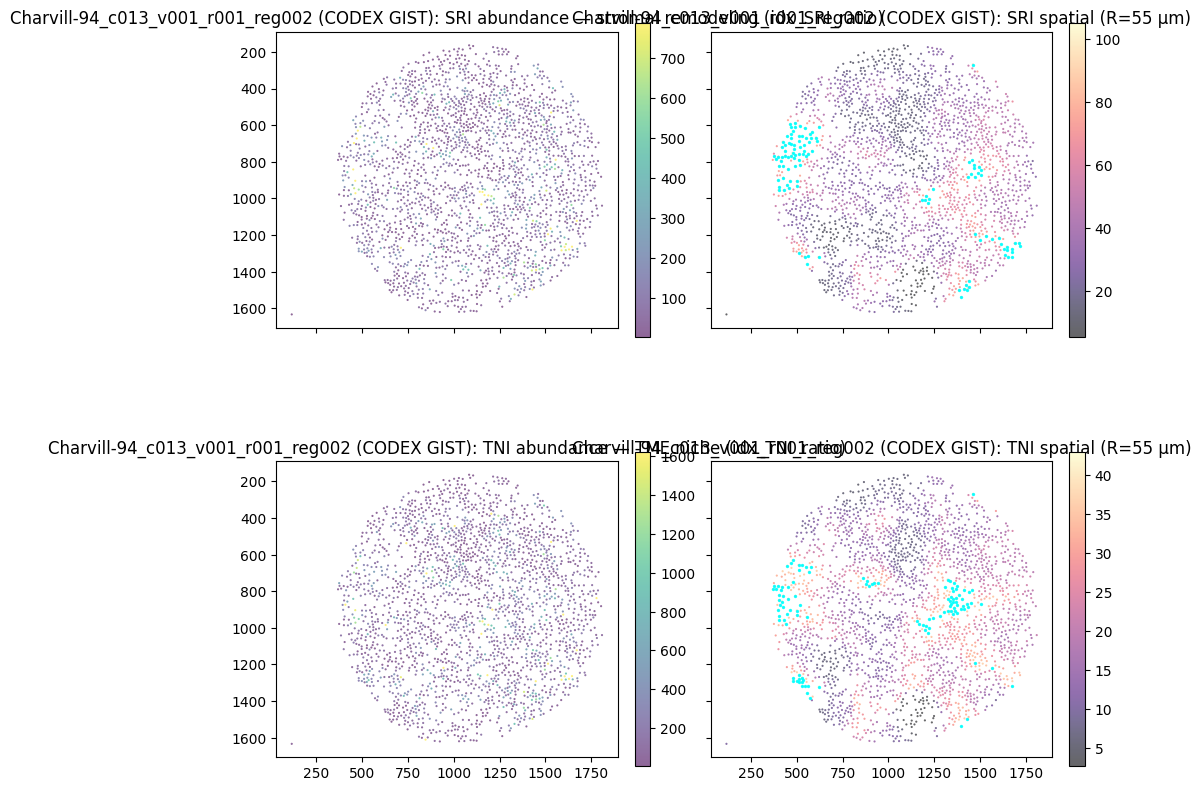

In [8]:
display(
    df_spatial[
        ["cell_id", "coord_x", "coord_y", "idx_SRI_ratio", "idx_SRI_spatial",
         "idx_TNI_ratio", "idx_TNI_spatial", "sri_candidate", "tni_candidate"]
    ]
    .sort_values("idx_TNI_spatial", ascending=False)
    .head(5)
)
gist_ni.plot_sri_tni_abundance_vs_spatial(
    df_spatial, f"{SAMPLE} (CODEX GIST)",
    radius_um=RADIUS_UM, figsize=(18.0 * 0.5, 10.0 * 0.5), dpi=150,
)
active = df_spatial["sri_candidate"] & df_spatial["tni_candidate"]
print(
    f"Active TME-niche cells (SRI ∩ TNI hotspot): {int(active.sum())} "
    f"({100 * active.mean():.2f}% of tissue)"
)


## 5. Hierarchical SRI → TNI (within-core quadrants)

Biological hierarchy: **Normal (Q1) → SRI↑ remodeling (Q2) → SRI↑+TNI↑ active niche (Q4)**.

Cross-core clinical comparisons use **Global Q4** and **active niche burden** in §6.


,quadrant,label,n_cells,percent
0,Q1,Normal / epithelial-dominant,2043,92.234763
1,Q2,Stromal remodeling (epithelial replacement by ...,61,2.753950
2,Q3,Immune / angiogenic activation without extensi...,61,2.753950
3,Q4,Active TME niche (fibroblasts + myeloid + endo...,50,2.257336


Spearman rho=0.881, p=0 | Q4 (active TME niche)=2.26%


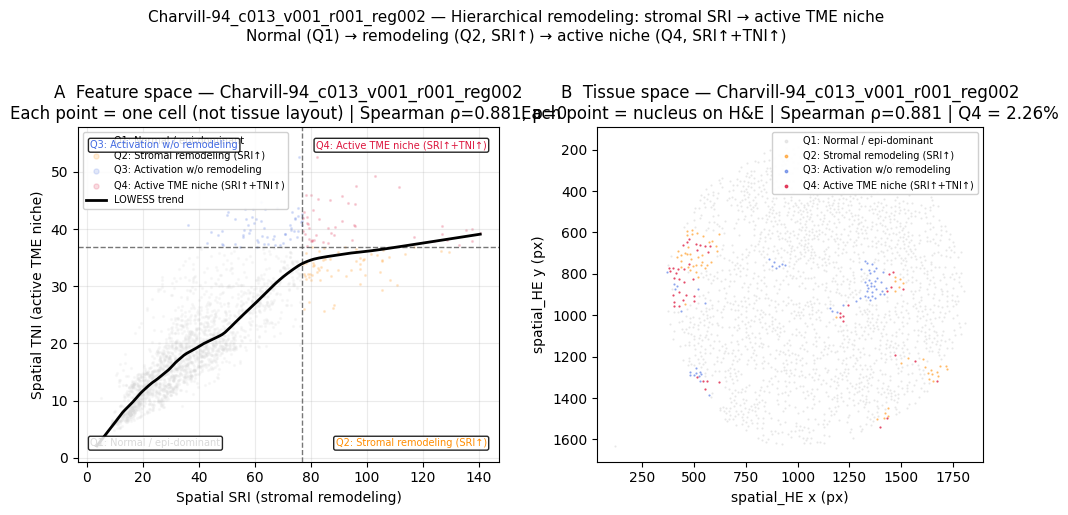

In [9]:
sri_tni_result = gist_ni.analyze_sri_tni_relationship(
    df_spatial, SAMPLE, plot=True, plot_layout="combined",
    figsize=(10, 5), figsize_scatter=(5.5, 5.5), figsize_spatial=(8.0, 8.0), dpi=150,
)
display(sri_tni_result["quadrant_table"])
print(
    f"Spearman rho={sri_tni_result['Spearman_rho']:.3f}, p={sri_tni_result['Spearman_p']:.2g} | "
    f"Q4 (active TME niche)={sri_tni_result['Q4_percent']:.2f}%"
)


## 6. Cohort: TME niche burden vs coverslip / SAMPLE_LABEL

| Metric | Definition |
|--------|------------|
| **Global Q4 %** | % cells with SRI and TNI ≥ cohort-pooled 95th percentiles |
| **Active niche burden** | `mean(√(SRI_i × TNI_i))` over matched nuclei |

Clinical groups: **coverslip**, **SAMPLE_LABEL** (`pan_organ="codex_gist"`).

Set `QUICK_VALIDATE = True` to load a few cores first. Full 550-core run is slow.


In [16]:
import importlib
importlib.reload(gist_ni)

# QUICK_VALIDATE = True    # load six cores
QUICK_VALIDATE = False    # load all 550 cores
COHORT_SAMPLES = ALL_SAMPLES[:6] if QUICK_VALIDATE else ALL_SAMPLES
print(f"Loading {len(COHORT_SAMPLES)} cores (QUICK_VALIDATE={QUICK_VALIDATE})")
print("Datasets:")
for i, sample in enumerate(COHORT_SAMPLES, start=1):
    print(f"  {i}. {sample}")

sample_dict = gist_ni.build_sample_dict(
    COHORT_SAMPLES, radius_um=RADIUS_UM, um_per_pixel=UM_PER_PX,
)
sri_tni_batch, cohort_meta = gist_ni.batch_analyze_sri_tni_cohort(sample_dict)
print(
    f"Cohort global cutoffs (p{cohort_meta['percentile']:.0f}, "
    f"n={cohort_meta['n_cells_pooled']:,} cells): "
    f"SRI={cohort_meta['sri_threshold_global']:.4f}, "
    f"TNI={cohort_meta['tni_threshold_global']:.4f}"
)
display(
    sri_tni_batch.sort_values("active_niche_burden", ascending=False)[
        ["Sample", "n_cells", "Q4_global_percent", "active_niche_burden",
         "SRI_median", "TNI_median", "Spearman_rho"]
    ].head()
)


Loading 550 cores (QUICK_VALIDATE=False)
Datasets:
  1. Charvill-94_c009_v001_r001_reg001
  2. Charvill-94_c009_v001_r001_reg002
  3. Charvill-94_c009_v001_r001_reg003
  4. Charvill-94_c009_v001_r001_reg004
  5. Charvill-94_c009_v001_r001_reg005
  6. Charvill-94_c009_v001_r001_reg006
  7. Charvill-94_c009_v001_r001_reg007
  8. Charvill-94_c009_v001_r001_reg008
  9. Charvill-94_c009_v001_r001_reg009
  10. Charvill-94_c009_v001_r001_reg010
  11. Charvill-94_c009_v001_r001_reg011
  12. Charvill-94_c009_v001_r001_reg012
  13. Charvill-94_c009_v001_r001_reg013
  14. Charvill-94_c009_v001_r001_reg014
  15. Charvill-94_c009_v001_r001_reg015
  16. Charvill-94_c009_v001_r001_reg016
  17. Charvill-94_c009_v001_r001_reg017
  18. Charvill-94_c009_v001_r001_reg018
  19. Charvill-94_c009_v001_r001_reg019
  20. Charvill-94_c009_v001_r001_reg020
  21. Charvill-94_c009_v001_r001_reg021
  22. Charvill-94_c009_v001_r001_reg022
  23. Charvill-94_c009_v001_r001_reg023
  24. Charvill-94_c009_v001_r001_reg02

/home/lingyu/ssd2/Python/Hist2Pheno/code/Hist2Pheno_pkg/histology_niche_index.py:935: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(sub[sri_col], sub[tni_col])
/home/lingyu/ssd2/Python/Hist2Pheno/code/Hist2Pheno_pkg/histology_niche_index.py:935: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(sub[sri_col], sub[tni_col])
/home/lingyu/ssd2/Python/Hist2Pheno/code/Hist2Pheno_pkg/histology_niche_index.py:935: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(sub[sri_col], sub[tni_col])


Cohort global cutoffs (p95, n=1,567,266 cells): SRI=88.0653, TNI=42.8534


/home/lingyu/ssd2/Python/Hist2Pheno/code/Hist2Pheno_pkg/histology_niche_index.py:935: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(sub[sri_col], sub[tni_col])
/home/lingyu/ssd2/Python/Hist2Pheno/code/Hist2Pheno_pkg/histology_niche_index.py:935: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(sub[sri_col], sub[tni_col])


,Sample,n_cells,Q4_global_percent,active_niche_burden,SRI_median,TNI_median,Spearman_rho
370,Charvill-94_c013_v001_r001_reg014,1500,63.333333,94.670632,105.670916,70.036922,0.948578
193,Charvill-94_c011_v001_r001_reg034,1981,52.852095,90.176410,152.176302,44.568961,0.930896
296,Charvill-94_c011_v001_r001_reg137,1322,51.134644,90.171326,172.857302,44.096168,0.944007
105,Charvill-94_c009_v001_r001_reg106,7041,32.694220,71.976666,84.653123,29.776384,0.931428
483,Charvill-94_c013_v001_r001_reg127,1622,40.012330,67.784381,92.994926,33.188484,0.977969


In [17]:
import importlib
import pandas as pd

import histology_derived_niche_index as hdni
import uni_label_cv_helpers as uni_nb
import s1167_plot
import s1167_histology_derived_niche_index as s1167_ni

importlib.reload(s1167_plot)
importlib.reload(hdni)
importlib.reload(uni_nb)
importlib.reload(s1167_ni)
importlib.reload(gist_ni)

from IPython.display import display

clinical_gist = gist_ni.recode_gist_tma_clinical(clinical)
clin_summary = gist_ni.summarize_gist_tma_clinical(clinical_gist)
print("GIST TMA clinical screening (raw fields)")
display(clin_summary)

print("\nRaw value counts (including NA)")
for col in gist_ni.GIST_TMA_CLINICAL_RAW_COLUMNS:
    if col not in clinical_gist.columns:
        print(f"  missing column: {col}")
        continue
    print(f"\n=== {col} ===")
    display(clinical_gist[col].value_counts(dropna=False).head(15).to_frame("n"))

print("\nRecoded groups (≤3 levels + Missing/Unknown/Control)")
for col in gist_ni.GIST_TMA_CLINICAL_GROUP_COLUMNS:
    if col not in clinical_gist.columns:
        continue
    print(f"\n=== {col} ===")
    display(clinical_gist[col].value_counts(dropna=False).to_frame("n"))

sri_tni_clinical = gist_ni.merge_batch_with_clinical(
    sri_tni_batch,
    clinical_gist,
    extra_clinical_columns=gist_ni.GIST_TMA_CLINICAL_GROUP_COLUMNS,
)
print(f"\nMerged cohort table: {len(sri_tni_clinical)} cores")


GIST TMA clinical screening (raw fields)


,column,n,n_missing,n_nonmissing,n_unique,present
0,tma_position,550,353,197,197,True
1,site,550,353,197,42,True
2,size,550,426,124,54,True
3,mitotic_rate,550,458,92,25,True
4,mutation_status,550,377,173,17,True
5,risk,550,377,173,9,True
6,primary,550,379,171,7,True



Raw value counts (including NA)

=== tma_position ===


,n
tma_position,
NaN,353
2_4_9,1
2_4_7,1
2_4_5,1
2_3_10,1
2_3_9,1
2_3_8,1
2_3_7,1
2_3_6,1



=== site ===


...


=== primary_group ===


,n
primary_group,
Missing,379
Primary,141
Metastasis,26
Unknown,4



=== tma_block ===


,n
tma_block,
Missing,353
4,101
2,96



Merged cohort table: 550 cores


### Coverslip (keep the original first panel)

Scatter legend is **coverslip** (3 colors), not individual cores. Pairwise Holm-adjusted Mann–Whitney U brackets are drawn on the boxes.


=== Global Q4 % vs coverslip ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,coverslip,Q4_global_percent,rank,Kruskal-Wallis,0.112856,4.363278,3,"[c009, c011, c013]","[0.0969843187801428, 0.35294117647058826, 0.37...","[0.0969843187801428, 0.35294117647058826, 0.37...",0.947474


Pairwise two-group tests (Holm-adjusted)


,group_a,group_b,n_a,n_b,test,statistic,p_value,p_adj,p_adjust_method,stars,clinical_variable,metric_col
0,c009,c011,160,197,Mann-Whitney U,14012.0,0.063384,0.190152,holm,ns,coverslip,Q4_global_percent
1,c009,c013,160,193,Mann-Whitney U,13759.0,0.070683,0.190152,holm,ns,coverslip,Q4_global_percent
2,c011,c013,197,193,Mann-Whitney U,19309.0,0.784289,0.784289,holm,ns,coverslip,Q4_global_percent



=== Active TME niche burden vs coverslip ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,coverslip,active_niche_burden,rank,Kruskal-Wallis,1.736896e-11,49.552672,3,"[c009, c011, c013]","[10.855452979266786, 18.976086189467914, 21.50...","[10.855452979266786, 18.976086189467914, 21.50...",10.760226


Pairwise two-group tests (Holm-adjusted)


,group_a,group_b,n_a,n_b,test,statistic,p_value,p_adj,p_adjust_method,stars,clinical_variable,metric_col
0,c009,c011,160,197,Mann-Whitney U,10187.5,9.136435e-09,1.827287e-08,holm,***,coverslip,active_niche_burden
1,c009,c013,160,193,Mann-Whitney U,9163.0,4.829345e-11,1.448804e-10,holm,***,coverslip,active_niche_burden
2,c011,c013,197,193,Mann-Whitney U,18263.0,5.021328e-01,5.021328e-01,holm,ns,coverslip,active_niche_burden


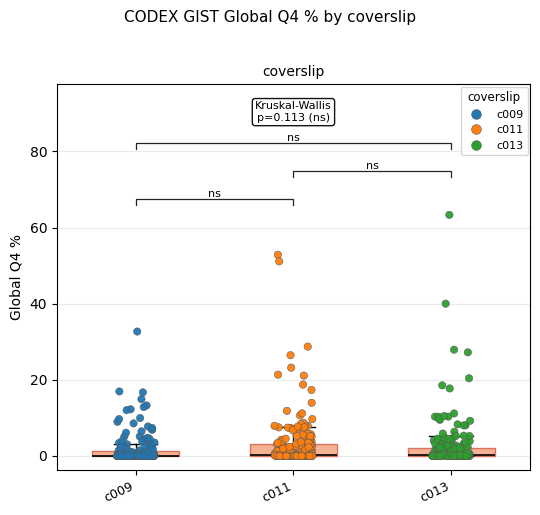

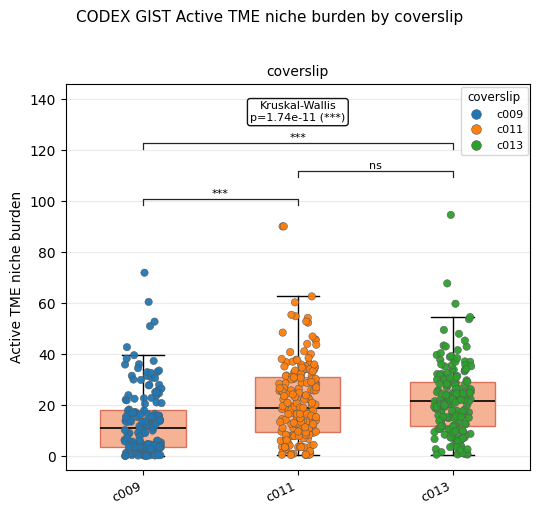

In [18]:
METRIC_SPECS = (
    ("Q4_global_percent", "Global Q4 %"),
    ("active_niche_burden", "Active TME niche burden"),
)


def _show_clinical_stats(stats):
    display(stats.drop(columns=["pairwise"], errors="ignore"))
    rows = []
    for _, row in stats.iterrows():
        items = row.get("pairwise")
        if not isinstance(items, (list, tuple)):
            continue
        for item in items:
            if not isinstance(item, dict):
                continue
            rec = dict(item)
            rec["clinical_variable"] = row.get("clinical_variable")
            rec["metric_col"] = row.get("metric_col")
            rows.append(rec)
    if rows:
        print("Pairwise two-group tests (Holm-adjusted)")
        display(pd.DataFrame(rows))


def plot_gist_niche_by_clinical(df, clinical_columns, group_name, figsize=(5.5, 5.0)):
    out = {}
    cols = tuple(clinical_columns)
    for metric, ylabel in METRIC_SPECS:
        stats = gist_ni.test_clinical_groups(
            df,
            metric_col=metric,
            clinical_cols=cols,
            alternative="two-sided",
            pairwise=True,
            pairwise_correction="holm",
        )
        print(f"\n=== {ylabel} vs {group_name} ===")
        _show_clinical_stats(stats)
        save_path = OUT_DIR / f"gist_{metric}_{'_'.join(cols)}_clinical.pdf"
        gist_ni.plot_clinical_comparison(
            df,
            stats,
            q4_col=metric,
            clinical_columns=cols,
            color_by="group",
            show_pairwise=True,
            show_sample_legend=False,
            figsize=figsize,
            legend_ncol=1,
            ylabel=ylabel,
            suptitle=f"CODEX GIST {ylabel} by {group_name}",
            save_path=save_path,
        )
        out[metric] = stats
    return out


gist_coverslip_stats = plot_gist_niche_by_clinical(
    sri_tni_clinical, ("coverslip",), "coverslip",
)

### Recoded GIST clinical variables

Each plot uses cores with a non-missing recoded label (`Missing` / `Unknown` / `Control` dropped). Scatter is colored by the 2–3 groups, not by sample.


site_group: 197 cores, 3 groups

=== Global Q4 % vs site_group ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,site_group,Q4_global_percent,rank,Kruskal-Wallis,0.015118,8.383785,3,"[Stomach, Small intestine, Other]","[0.47718461079630187, 1.36986301369863, 0.1207...","[0.47718461079630187, 1.36986301369863, 0.1207...",1.820516


Pairwise two-group tests (Holm-adjusted)


,group_a,group_b,n_a,n_b,test,statistic,p_value,p_adj,p_adjust_method,stars,clinical_variable,metric_col
0,Stomach,Small intestine,71,51,Mann-Whitney U,1604.0,0.278142,0.278142,holm,ns,site_group,Q4_global_percent
1,Stomach,Other,71,75,Mann-Whitney U,3148.5,0.049595,0.099191,holm,ns,site_group,Q4_global_percent
2,Small intestine,Other,51,75,Mann-Whitney U,2450.0,0.005940,0.017819,holm,*,site_group,Q4_global_percent



=== Active TME niche burden vs site_group ===


...

,group_a,group_b,n_a,n_b,test,statistic,p_value,p_adj,p_adjust_method,stars,clinical_variable,metric_col
0,2,4,96,101,Mann-Whitney U,4781.0,0.86464,0.86464,none,ns,tma_block,Q4_global_percent



=== Active TME niche burden vs tma_block ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,tma_block,active_niche_burden,rank,Mann-Whitney U,0.436103,5160.0,2,"[2, 4]","[20.809137601872962, 17.84195677728956]","[20.809137601872962, 17.84195677728956]",0.360411


Pairwise two-group tests (Holm-adjusted)


,group_a,group_b,n_a,n_b,test,statistic,p_value,p_adj,p_adjust_method,stars,clinical_variable,metric_col
0,2,4,96,101,Mann-Whitney U,5160.0,0.436103,0.436103,none,ns,tma_block,active_niche_burden


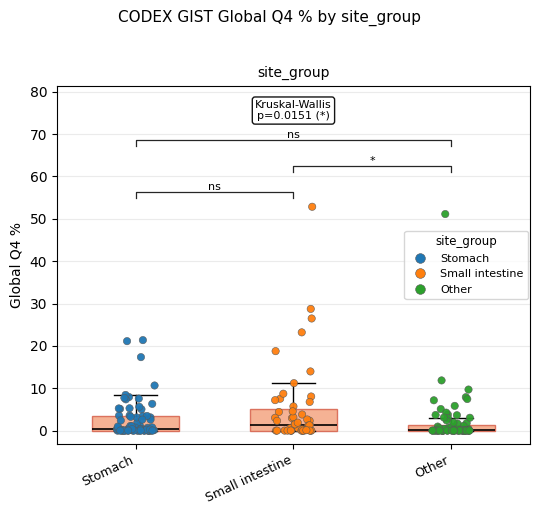

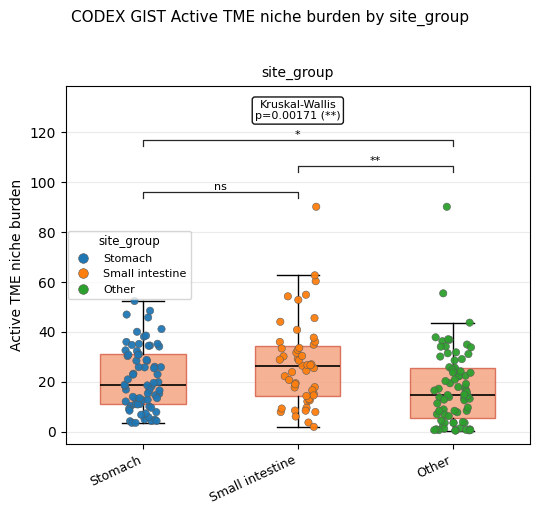

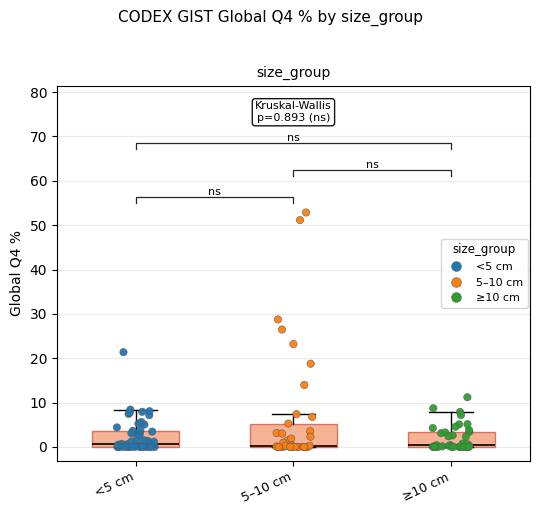

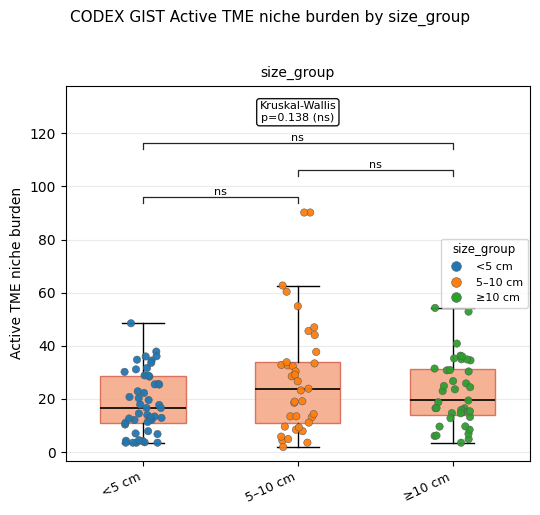

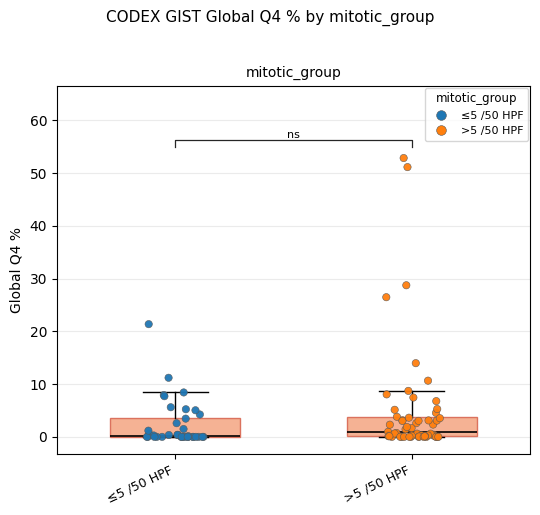

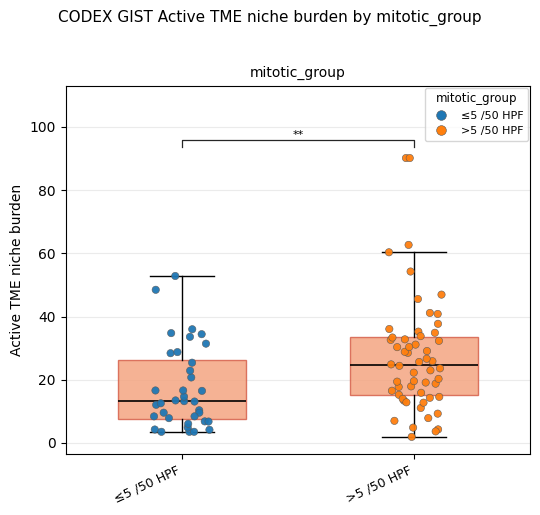

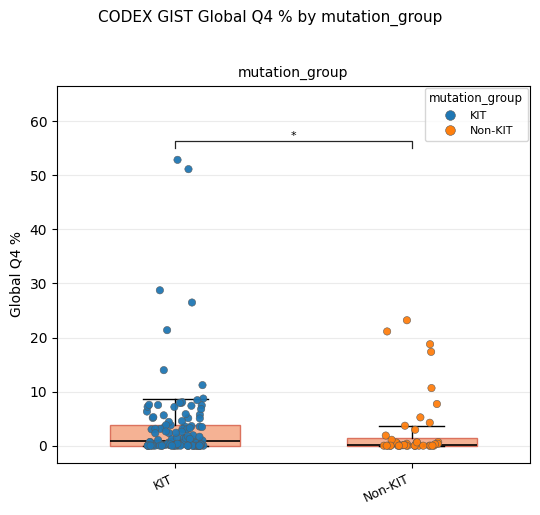

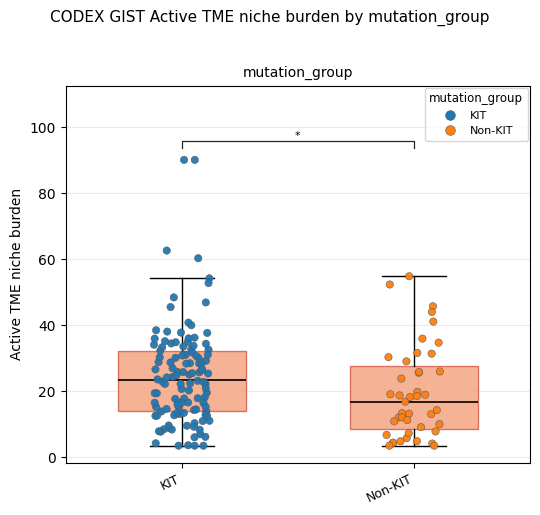

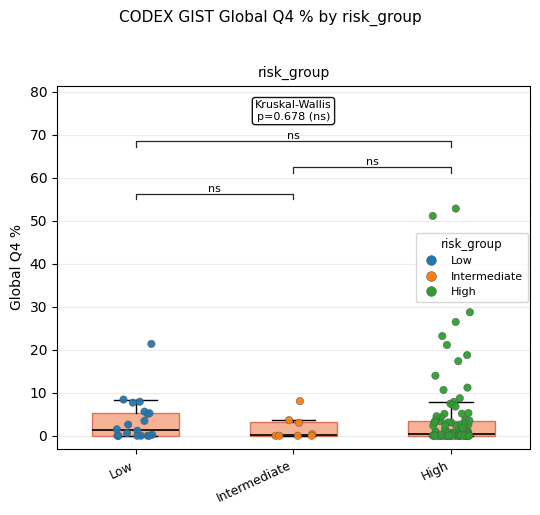

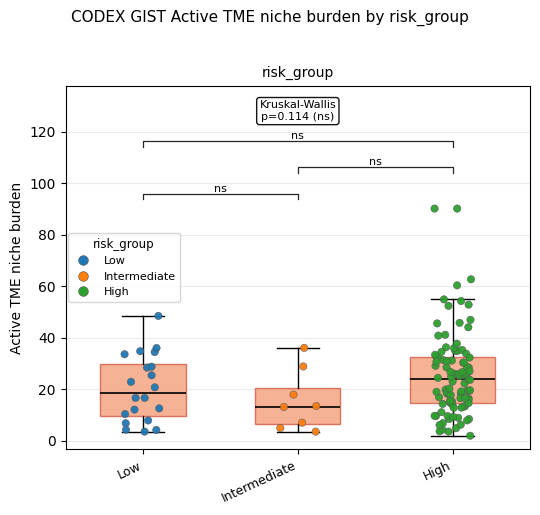

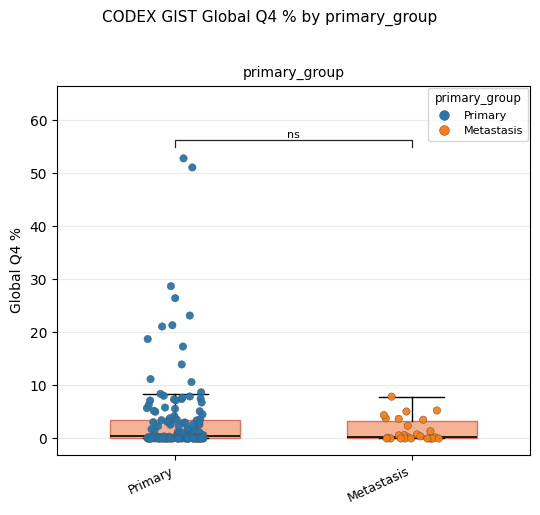

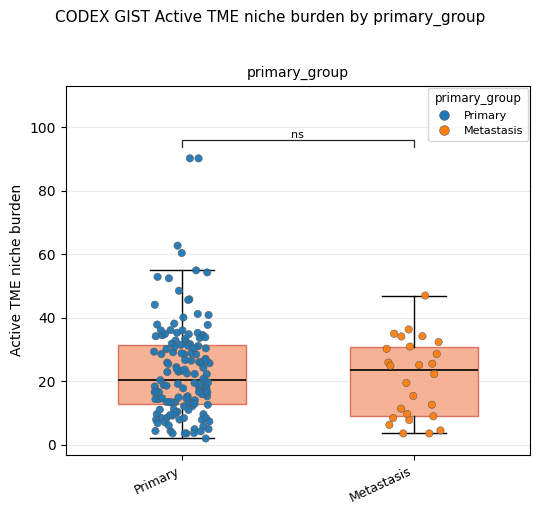

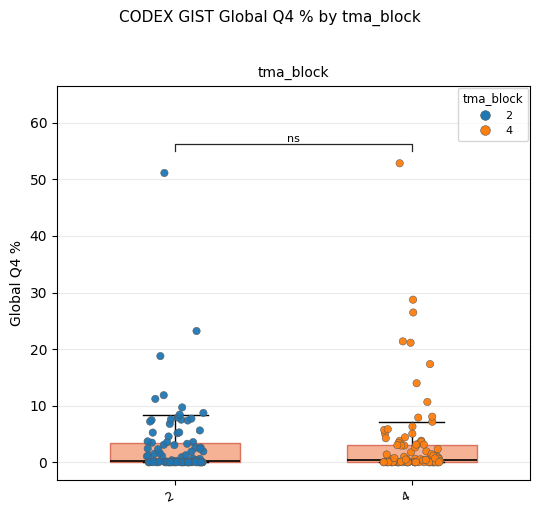

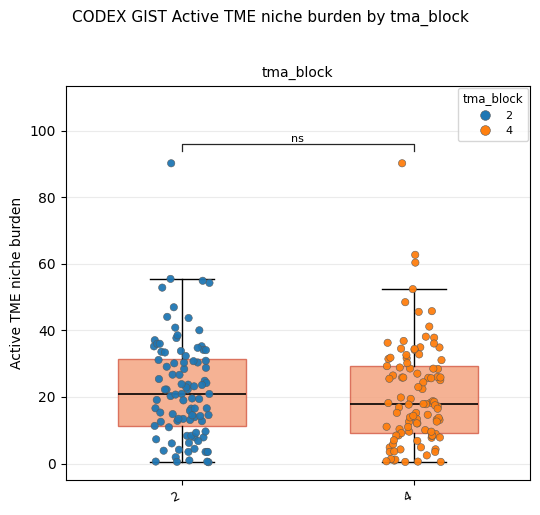

In [19]:
DROP_LEVELS = {"Missing", "Unknown", "Control", "nan", "None"}
gist_clinical_stats = {}
for col in gist_ni.GIST_TMA_CLINICAL_GROUP_COLUMNS:
    if col not in sri_tni_clinical.columns:
        continue
    sub = sri_tni_clinical.loc[~sri_tni_clinical[col].astype(str).isin(DROP_LEVELS)].copy()
    n_lv = sub[col].nunique(dropna=True)
    print(f"\n{'=' * 60}\n{col}: {len(sub)} cores, {n_lv} groups")
    if n_lv < 2 or len(sub) < 8:
        print("  skip (need ≥2 groups and enough cores)")
        continue
    gist_clinical_stats[col] = plot_gist_niche_by_clinical(
        sub, (col,), col, figsize=(5.5, 5.0),
    )

## 7. SAMPLE_LABEL-level source decomposition

GIST has no immunotherapy Response. This section:

1. Computes core-level **SRI_mean**, **TNI_mean**, **Epi_local_mean**, **TNI_numerator_mean**.
2. Averages those metrics within `SAMPLE_LABEL` (one point per TMA donor).
3. Tests and plots the donor-level metrics vs **coverslip** (`c009` / `c011` / `c013`).

Requires `sample_dict` from §6.


In [22]:
source = gist_ni.summarize_source_metrics(sample_dict)
region_source = sri_tni_clinical.merge(
    source.drop(columns=["n_cells"], errors="ignore"), on="Sample", how="left",
)
print("Cores:", len(region_source), "| SAMPLE_LABEL:", region_source["SAMPLE_LABEL"].nunique())

patient_source = gist_ni.aggregate_metrics_by_patient(region_source)
patient_source_stats = gist_ni.test_source_metrics(
    patient_source, clinical_cols=("coverslip",),
)
print("=== SAMPLE_LABEL-level vs coverslip (mean of cores) ===")
display(patient_source)
_show_clinical_stats(patient_source_stats)


Cores: 550 | SAMPLE_LABEL: 358
=== SAMPLE_LABEL-level vs coverslip (mean of cores) ===


,SAMPLE_LABEL,n_regions,n_cells,active_niche_burden,Q4_global_percent,SRI_mean,TNI_mean,SRI_median,TNI_median,Epi_local_mean,TNI_numerator_mean,Fib_local_mean,M2_local_mean,Endo_local_mean,coverslip
0,TA-339_1,1,5257,1.546804,0.000000,5.741179,0.571885,2.379035,0.277254,0.263529,0.074719,0.595975,0.025099,0.039027,c009
1,TA-339_10,1,144,3.510574,0.000000,3.585793,3.436932,3.585793,3.436932,0.031849,0.109462,0.114204,0.112172,0.102384,c009
2,TA-339_100,1,1856,1.721938,0.000000,1.474639,2.160522,0.186423,0.233818,0.355068,0.090943,0.068746,0.099924,0.124288,c009
3,TA-339_101,1,175,3.510574,0.000000,3.585793,3.436932,3.585793,3.436932,0.031849,0.109462,0.114204,0.112172,0.102384,c009
4,TA-339_102,1,2095,13.889982,0.620525,10.067046,21.760880,3.977525,10.210553,0.016975,0.084624,0.047624,0.092856,0.236917,c009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,TA-429A_95,1,3164,12.616260,0.695322,18.560012,8.688557,12.575617,6.246479,0.021226,0.091217,0.186227,0.131819,0.032372,c011
354,TA-429A_96,1,876,27.003022,2.625571,43.753239,17.887544,32.700940,13.509335,0.010829,0.110560,0.251949,0.126885,0.057557,c011
355,TA-429A_98,1,738,22.972977,3.116531,29.137148,18.753680,21.938366,16.305539,0.012729,0.155433,0.214258,0.147789,0.148104,c011
356,TA-429A_99,1,1613,15.226114,0.743955,21.482134,10.914320,17.270713,8.987327,0.021607,0.149039,0.287891,0.128301,0.096870,c011


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,pairwise,neg_log10_p
0,coverslip,SRI_mean,rank,Mann-Whitney U,4.907271e-12,9060.5,2,"[c009, c011]","[11.177899298149399, 26.263613109787816]","[11.177899298149399, 26.263613109787816]","[{'group_a': 'c009', 'group_b': 'c011', 'n_a':...",11.309160
1,coverslip,TNI_mean,rank,Mann-Whitney U,9.696608e-05,11979.5,2,"[c009, c011]","[8.468369591287438, 14.085520481382897]","[8.468369591287438, 14.085520481382897]","[{'group_a': 'c009', 'group_b': 'c011', 'n_a':...",4.013380
2,coverslip,Epi_local_mean,rank,Mann-Whitney U,9.389175e-09,21328.0,2,"[c009, c011]","[0.028600809729001968, 0.01237372647205049]","[0.028600809729001968, 0.01237372647205049]","[{'group_a': 'c009', 'group_b': 'c011', 'n_a':...",8.027373
3,coverslip,TNI_numerator_mean,rank,Mann-Whitney U,7.361652e-04,12486.0,2,"[c009, c011]","[0.09892232142274089, 0.10666607282444371]","[0.09892232142274089, 0.10666607282444371]","[{'group_a': 'c009', 'group_b': 'c011', 'n_a':...",3.133025


(<Figure size 1680x520 with 4 Axes>,
 array([[<Axes: title={'center': 'SRI  (Fib / Epi)'}, ylabel='mean per region or patient'>,
         <Axes: title={'center': 'TNI  (geomean / Epi)'}>,
         <Axes: title={'center': 'Epi_local'}>,
         <Axes: title={'center': 'TNI numerator  (Fib × myeloid × Endo)'}>]],
       dtype=object))

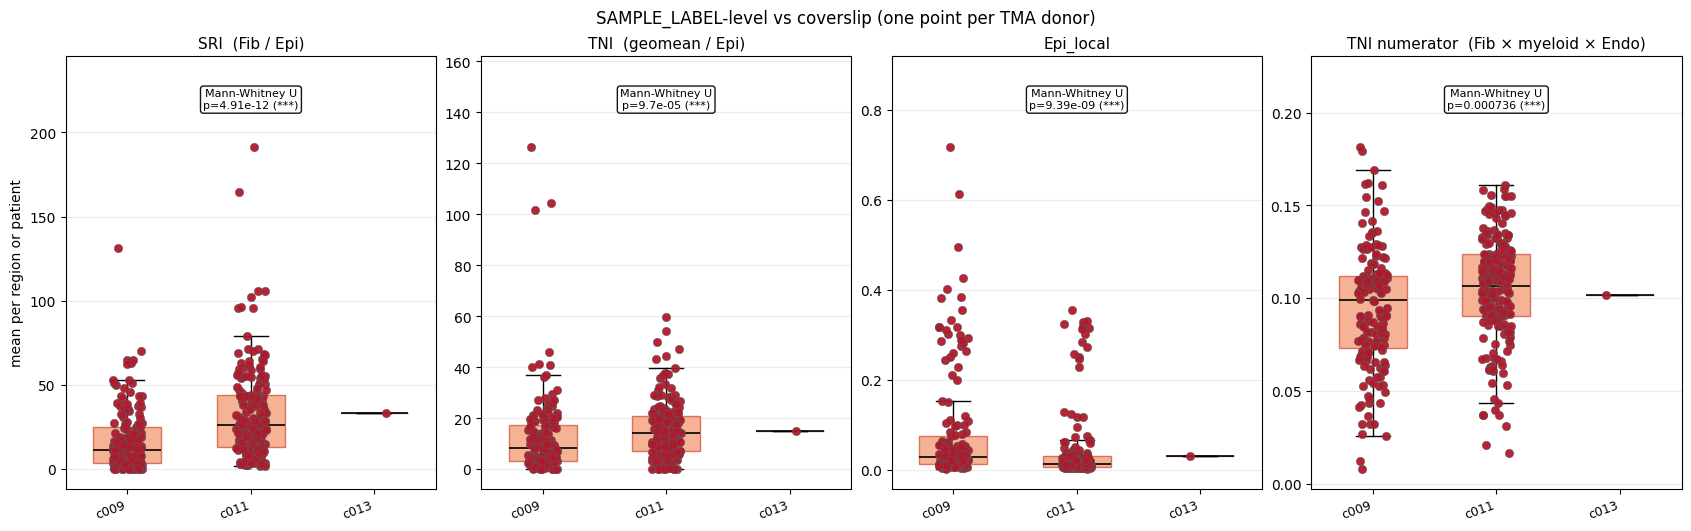

In [23]:
import importlib
import histology_niche_index as _hni

importlib.reload(_hni)

gist_ni.plot_source_metric_grid(
    patient_source, patient_source_stats,
    sample_col=None, group_col="coverslip",
    color_by="group", show_pairwise=True,
    suptitle="SAMPLE_LABEL-level vs coverslip (one point per TMA donor)",
)
